In [1]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 10, 15, 19, 22, 25, 27, 31, 35])

nb_name = "03_normalization_batch_correction.ipynb"

_compare_version(nb_name)

# 03 - Normalization and Batch effect correction
<hr style="border:2px solid black"> </hr>

## 1 - Description

Similar to quality control and filtering this step is aimed to prepare the data to facilitate better results in the following analysis steps. However, with normalization and batch effect correction the aim is to refine the data points in a way that

1. comparability between e.g. samples is enhanced
2. the influence of outliers is mitigated
3. variances introduced by technical or otherwise unwanted sources are omitted from the dataset.

Since this reduces the overall noise, the embedding and clustering steps in particular benefit from these adjustments.

___________

## 2 - Setup

In [2]:
import pandas as pd
import scanpy as sc

import sctoolbox
import sctoolbox.utils as utils
import sctoolbox.tools as tools
import sctoolbox.plotting as pl

sctoolbox.settings.settings_from_config("config.yaml", key="03")

# Set additional options for figures
sc.set_figure_params(vector_friendly=True, dpi_save=600, scanpy=False)

[WARNING] Log file '../logs/03_log.txt' already exists. The file will be overwritten since 'overwrite_log' is set to True.


___________

## 3 - Load anndata
Loads the anndata.h5ad from the last notebook and provides a basic overview.

In [3]:
adata = utils.adata.load_h5ad("anndata_2.h5ad")

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

[INFO] The adata object was loaded from: ../adatas/anndata_2.h5ad


AnnData object with n_obs × n_vars = 3344 × 57031
    obs: 'TubeID', 'meta_TubeID', 'meta_pop_export_psn', 'meta_pop_visit_1_date', 'meta_pop_visit_2_date', 'meta_pop_visit_3_date', 'meta_pop_visit_4_date', 'meta_pop_age', 'meta_pop_age_dec', 'meta_pop_sex', 'meta_pop_c19_severity', 'meta_pop_cohort', 'meta_suep_hap_export_psn', 'meta_suep_hap_baseline_date', 'meta_suep_hap_end_acute_date', 'meta_suep_hap_end_acute_visit_date', 'meta_suep_hap_m3_fu_date', 'meta_suep_hap_m6_fu_date', 'meta_suep_hap_m12_fu_date', 'meta_suep_hap_m24_fu_date', 'meta_suep_hap_age', 'meta_suep_hap_age_dec', 'meta_suep_hap_sex', 'meta_suep_hap_c19_severity', 'meta_suep_hap_cohort', 'meta_export_psn', 'meta_age', 'meta_age_dec', 'meta_sex', 'meta_c19_severity', 'meta_cohort', 'rna_TubeID', 'rna_id', 'rna_fastq1', 'rna_project', 'rna_run', 'rna_plate', 'rna_organism', 'rna_assembly', 'rna_release', 'rna_parameters', 'rna_reads_processed', 'rna_reads_with_exactly_1_alignment', 'rna_reads_with_multiple_alignments

,TubeID,meta_TubeID,meta_pop_export_psn,meta_pop_visit_1_date,meta_pop_visit_2_date,meta_pop_visit_3_date,meta_pop_visit_4_date,meta_pop_age,meta_pop_age_dec,meta_pop_sex,meta_pop_c19_severity,meta_pop_cohort,meta_suep_hap_export_psn,meta_suep_hap_baseline_date,meta_suep_hap_end_acute_date,meta_suep_hap_end_acute_visit_date,meta_suep_hap_m3_fu_date,meta_suep_hap_m6_fu_date,meta_suep_hap_m12_fu_date,meta_suep_hap_m24_fu_date,meta_suep_hap_age,meta_suep_hap_age_dec,meta_suep_hap_sex,meta_suep_hap_c19_severity,meta_suep_hap_cohort,meta_export_psn,meta_age,meta_age_dec,meta_sex,meta_c19_severity,meta_cohort,rna_TubeID,rna_id,rna_fastq1,rna_project,rna_run,rna_plate,rna_organism,rna_assembly,rna_release,rna_parameters,rna_reads_processed,rna_reads_with_exactly_1_alignment,rna_reads_with_multiple_alignments,rna_reads_with_no_alignment,rna_reads_aligned,rna_pct_reads_aligned,rna_duplicate_reads,rna_pct_duplicate_reads,rna_mitochondrial_reads,rna_pct_mitochondrial_reads,rna_rrna_subunit_reads,rna_pct_rrna_subunit_reads,rna_pcr_bottleneck_coefficient,rna_mean_fragment_size_(only_for_paired-end),rna_reads_used_after_filters,rna_parameters.1,rna_reads_processed.1,rna_reads_assigned,rna_pct_reads_assigned_total,rna_pct_features_with_cpm_at_least_0.5,rna_unass._reads_overlapping_multiple_genes,rna_unass._reads_mapping_to_multiple_locations,rna_unass._reads_mapping_to_no_feature,rna_unass._reads_not_mapping,rna_unass._reads__bad_mapping_quality,rna_unass._reads__low_fragment_length,rna_unass._chimeric_reads,mapped_reads_over_2000000,rna_DDX3Y,rna_XIST,rna_gender,rna_sample_id_original,rna_plate_id_original,filename,rel_path,n_genes,log1p_n_genes,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,total_counts_is_gender,log1p_total_counts_is_gender,pct_counts_is_gender
rna project.run id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
plt1.run1 pat_88,LV1007699778,LV1007699778,0,0,0,0,0,0.0,0,0,0,0,hap_0178,17/11/2021,24/11/2021,24/11/2021,0,0,0,0,65.0,60-69,M,severe,hap,hap_0178,65.0,60-69,M,severe,hap,LV1007699778,pat_88,AAAVY52HV_NAPKON_Plate1_2_22s004137-1-1_Valasa...,plt1,run1,plate1,human,hg38,104.0,"mode: single-end, keep duplicates: no, keep mu...","29,112,743","23,152,813","4,044,454","1,915,476","27,197,267",93.0,"20,093,139",73.0,"1,714,158",6.0,"1,868,907",6.0,0.28,0.0,"6,644,895",-t exon -g gene_id -s 2; multi-mapping: no; du...,"6,644,895","4,810,861",16.0,49.0,216.360,0.0,"1,617,674",0.0,0.0,0.0,0.0,True,844.0,8.0,M,Sample 49,Plate 1,matrix.mtx,.,23151,10.049836,4810335.0,15.386277,0.0,0.0,0.0,52602.0,10.870528,1.093521,155239.0,11.952727,3.227197
plt1.run1 pat_89,LV1007699743,LV1007699743,0,0,0,0,0,0.0,0,0,0,0,suep_0425,08/11/2021,17/11/2021,17/11/2021,0,0,0,0,61.0,60-69,M,mild,suep,suep_0425,61.0,60-69,M,mild,suep,LV1007699743,pat_89,AAAVY52HV_NAPKON_Plate1_2_22s004137-1-1_Valasa...,plt1,run1,plate1,human,hg38,104.0,"mode: single-end, keep duplicates: no, keep mu...","24,355,220","13,253,462","7,713,379","3,388,379","20,966,841",86.0,"17,678,467",84.0,"1,475,002",7.0,"6,372,269",30.0,0.22,0.0,"2,989,995",-t exon -g gene_id -s 2; multi-mapping: no; du...,"2,989,995","2,155,768",8.0,45.0,97.961,0.0,"736,266",0.0,0.0,0.0,0.0,True,670.0,4.0,M,Sample 50,Plate 1,matrix.mtx,.,20116,9.909321,2155449.0,14.583510,0.0,0.0,0.0,31098.0,10.344931,1.442762,71203.0,11.173305,3.303395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
plt49.run1 pat_3571,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0.00,0.0,0,0

,Ensembl_gene_id,Ensembl_biotype,UniProt_proteins,UniProt_genes,UniProt_accessions,UniProt_names,UniProt_Ensembl_transcripts,UniProt_Ensembl_proteins,UniProt_Ensembl_gene_ids,Ensembl_chr,Ensembl_start,Ensembl_stop,Ensembl_strand,KEGG_PATHWAY_terms,KEGG_PATHWAY_ids,Gene_Ontology_terms,Gene_Ontology_ids,is_mito,is_ribo,is_gender,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Ensembl gene,,,,,,,,,,,,,,,,,,,,,,,,,,
SDK1,ENSG00000146555,protein_coding,Protein sidekick-1,SDK1,Q7Z5N4; F8W6X9; A0A087WTQ6,SDK1_HUMAN; F8W6X9_HUMAN; A0A087WTQ6_HUMAN,ENST00000404826; ENST00000389531; ENST00000615806,ENSP00000385899; ENSP00000374182; ENSP00000478062,ENSG00000146555,chr7,3301252,4269000,+,0,0,"eye development, neural retina development, bi...","GO:0001654, GO:0003407, GO:0005488, GO:0005515...",False,False,False,2645,2.618957,1.286186,27.751980,9588.0,9.168372
ENSG00000283537,ENSG00000283537,transcribed_unprocessed_pseudogene,0,0,0,0,0,0,ENSG00000283537,chr7,143620943,143645675,+,0,0,0,0,False,False,False,808,0.479650,0.391806,77.929527,1756.0,7.471363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000270696,ENSG00000270696,lncRNA,0,0,0,0,0,0,ENSG00000270696,chr2,75660462,75662208,+,0,0,0,0,False,False,False,1,0.000273,0.000273,99.972685,1.0,0.693147
SNRPGP11,ENSG00000229906,processed_pseudogene,0,0,0,0,0,0,ENSG00000229906,chr13,51496020,51496251,-,0,0,0,0,False,False,False,1,0.000273,0.000273,99.972685,1.0,0.693147


In [73]:
adata.obs['pct_counts_is_gender']

rna project.run id
plt1.run1 pat_88       3.227197
plt1.run1 pat_89       3.303395
plt1.run1 pat_91       3.195135
plt1.run1 pat_92       3.261343
plt1.run1 pat_93       3.231386
                         ...   
plt49.run1 pat_3568    3.223321
plt49.run1 pat_3569    3.373135
plt49.run1 pat_3570    3.349904
plt49.run1 pat_3571    3.317944
plt49.run1 pat_3572    3.309546
Name: pct_counts_is_gender, Length: 3344, dtype: float32

___________

## 4 - General input
<hr style="border:2px solid black"> </hr>

### 4.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| species | The species of your data | `human`, `mouse`, `zebrafish`, `rat` |
| groupby | The name of a column in `adata.obs` to **plot** cell cycle phase cell counts per group | e.g. `sample` or `condition` column. If None, the counts for each phase in the whole dataset will be plotted |
| threads | the number of cores to use for multiprocessing | Default 4 |
| batch_column | For **batch correction**: A column in `adata.obs` (see table above) containing batch information | e.g. `batch` |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
species = "human"

groupby = 'meta_age_dec'

threads = 4

batch_column = "rna_plate"

---------

In [5]:
# Ensure that the batch column is of type category
adata.obs[batch_column] = adata.obs[batch_column].astype(str).astype("category")

---------

## 5 - Plot highly expressed genes
<hr style="border:2px solid black"> </hr>

Show the top expressing genes to decide whether they should be included during the normalization (they are not removed from the dataset just excluded during normalization).

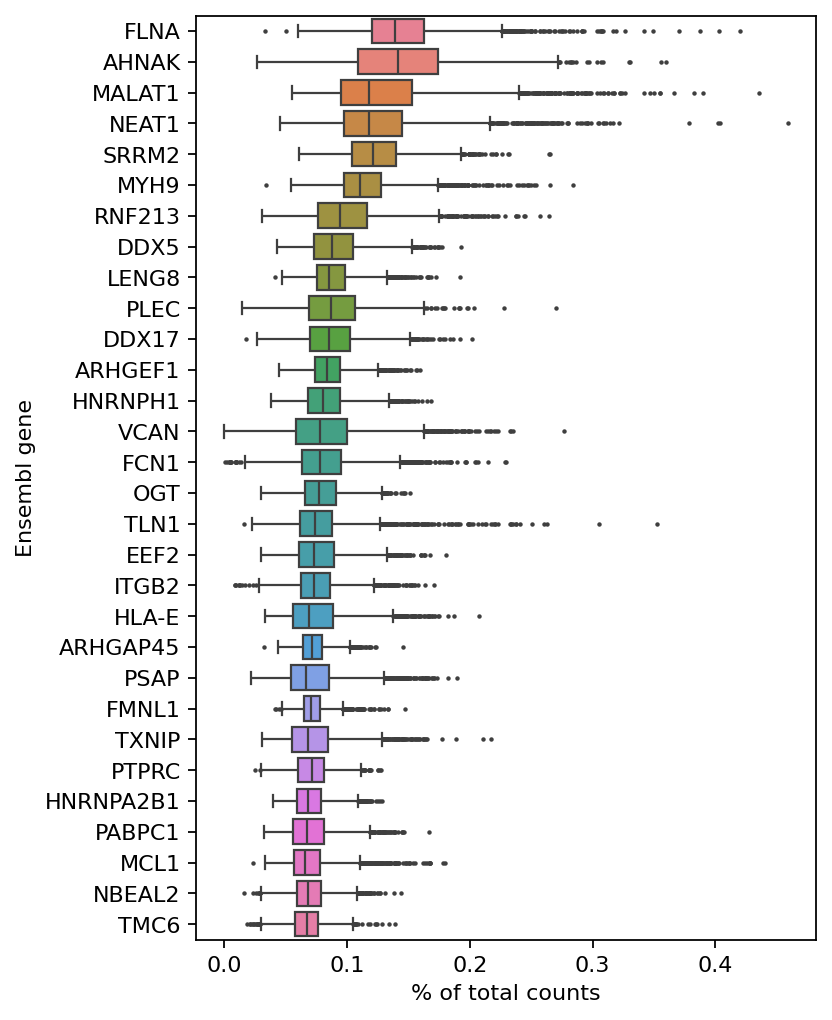

In [6]:
sc.pl.highest_expr_genes(adata, show=False)
pl.general._save_figure("highly_expressed.pdf")

### 5.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| exclude_highly_expressed | Choose if highly expressed genes should be excluded | `True` or `False` |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [7]:
exclude_highly_expressed = False

-------------

## 6 - Normalization
<hr style="border:2px solid black"> </hr>

This section performs the normalization followed by a dimension reduction. The counts for each cell are normalized so that all cells have the same number of counts after normalization. This removes imbalances due to sampling effects or sequencing depth to make the cells comparable.

To normalize the data we use a combination of the scanpy functions **sc.pp.normalize_total()** and **sc.pp.log1p()**. Hereby we aim to remove variability introduced by the sequencing depth by **sc.pp.normalize_total()**, which is basically a scaling resulting in values between 0 and 1. The function **sc.pp.log1p()** removes outliers by applying $f(x)=log(x+1)$ to the data.

**DOI: https://doi.org/10.1038/s41576-023-00586-w**

In [8]:
# Save a layer called raw before normalization
adata.layers["raw"] = adata.X.copy()

In [9]:
adata = tools.norm_correct.normalize_adata(adata, method="total", target_sum=None, exclude_highly_expressed=exclude_highly_expressed)

[INFO] Performing total normalization and PCA...


----------

## 7 - Predict Cell Cycle
Predict the division phase of each cell.

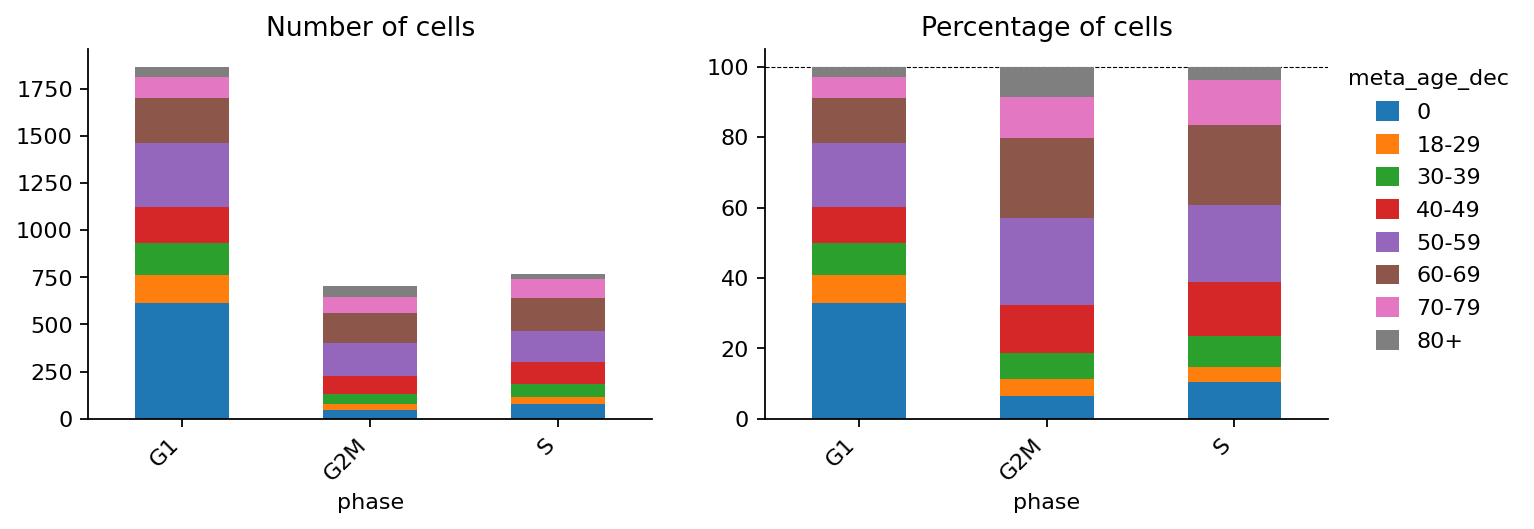

In [10]:
tools.qc_filter.predict_cell_cycle(adata, species=species, s_genes=None, g2m_genes=None, inplace=True,
                                   groupby=groupby,
                                   save="cell_distribution_phase_barplot.pdf")

-----------

## 8 - Find highly variable genes
<hr style="border:2px solid black"> </hr>

Identify genes that rapidly change expression levels between cells. These genes are considered to be highly informative about the underlying biological structure.

### 8.1 - Parameter Overview

Try to find the optimal parameter combination using the boundaries below

| Parameter | Description | Options |
|-----------|-------------|---------|
| min_limit | Minimum amount of expected variable genes | Default 1000 |
| max_limit | Maximum amount of expected variable genes | Default 5000 |
| min_disp | The minimum allowed spread the distribution of a gene can have | Default 0.5 |
| max_disp | The maximum allowed spread the distribution of a gene can have | Default `inf` |
| min_mean | Minimum allowed mean gene expression | Default 0.0125 |
| max_mean | Maximum allowed mean gene expression | Default 3 |

For more information see:

https://loosolab.pages.gwdg.de/software/sc_framework/API/tools.html#sctoolbox.tools.highly_variable.annot_HVG

https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html#scanpy-pp-highly-variable-genes

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [70]:
%bgcolor PowderBlue

min_limit = 2000
max_limit = 5000 
min_disp = 1
max_disp = float('20')
min_mean = 0.05
max_mean = 8

[INFO] Annotating highy variable genes (HVG)
[INFO] Total HVG=3821


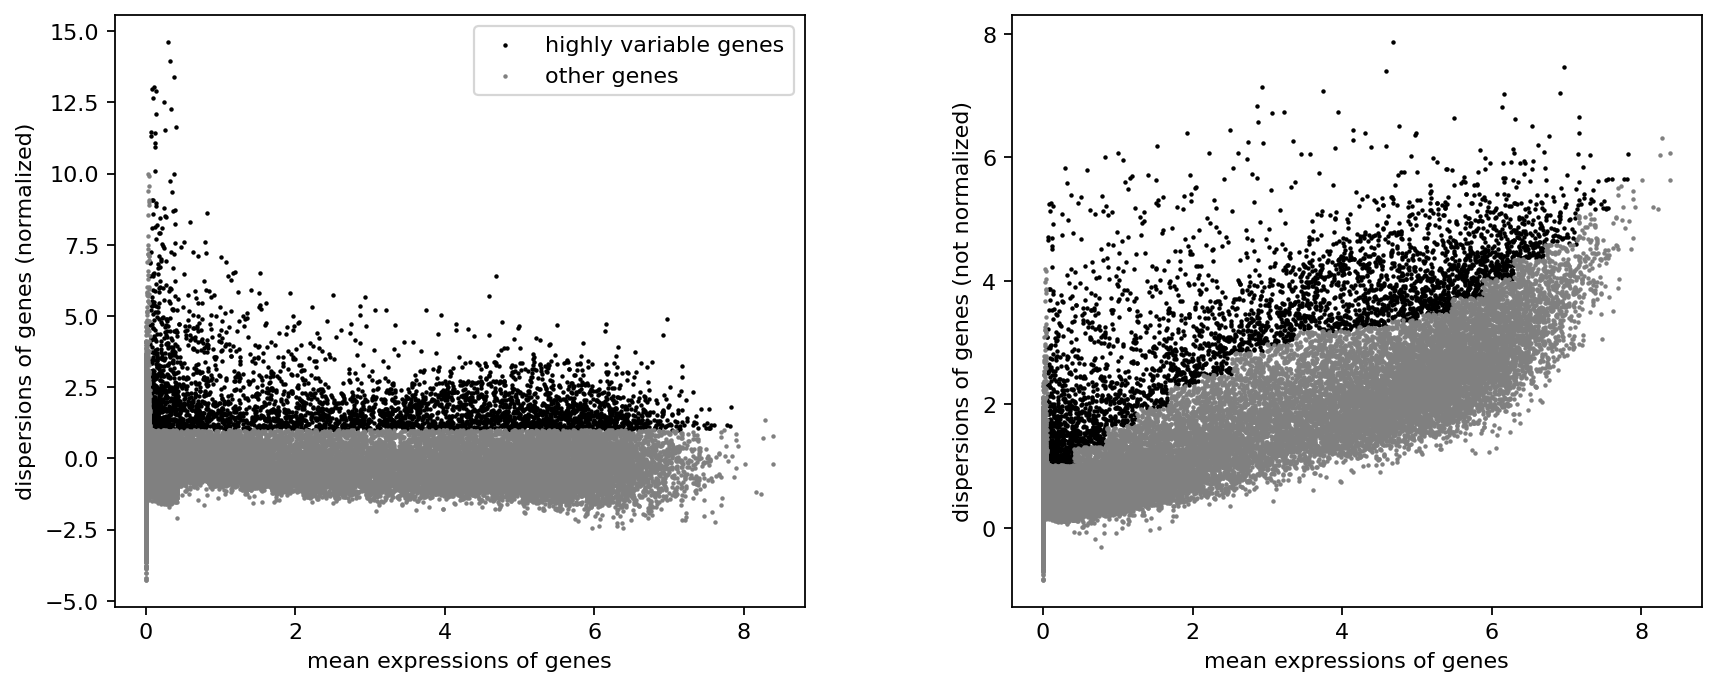

In [71]:
tools.highly_variable.annot_HVG(
    adata, 
    hvg_range=(min_limit, max_limit),
    min_disp=min_disp,
    max_disp=max_disp,
    min_mean=min_mean,
    max_mean=max_mean,
    save="highly_variable.pdf"
)

In [50]:
# Number of variable genes selected
adata.var["highly_variable"].sum()

3572

---------

## 9 - PCA and neighbors for uncorrected data
<hr style="border:2px solid black"> </hr>

Another important property of our data is its high dimensionality. However, this complexity hinders in-depth analysis e.g. the identification of cell states. Thus, dimension reduction algorithms are applied to reduce complexity while simultaneously retaining patterns, a crucial step to enable embedding and clustering. In other words, noise is reduced by removing low variance components as well as components explaining technical or otherwise unwanted factors (e.g. number of active genes, cell cycle, etc.) which also has the benefit of reducing the computational demand.

**DOI: [10.1038/nmeth.4346](https://doi.org/10.1038/nmeth.4346)**  

The following heatmaps and barplots are intended to identify potentially unwanted PCs by showing the PCs in combination with available observations (cell-related metrics) and variables (gene-related metrics). In general, **selected PCs should avoid correlations with metrics**, but the importance of metrics and the stringency of thresholds depends on the experiment and the underlying questions, and therefore requires careful consideration by the analyst.

In [37]:
default_pca_color = [k for k in adata.uns["sctoolbox"]["report"]["qc"]["obs"]["threshold"].keys() if k not in ["before", "after"]] + ["phase", batch_column]
default_pca_color

['log1p_total_counts',
 'n_genes',
 'pct_counts_is_gender',
 'pct_counts_is_mito',
 'pct_counts_is_ribo',
 'phase',
 'rna_plate']

In [46]:
sctoolbox.tools.dim_reduction.compute_PCA(adata, svd_solver='arpack', mask_var="highly_variable", inplace=True)

[INFO] Computing PCA


### 9.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| n_pcs_heatmap | number of PCs shown within the heatmap | Default 15 |
| pca_color | columns in `adata.obs`or `adata.var` to be shown in the following PCA | list of **column names** (e.g. `[obs_column1, obs_column2, var_column2]`) or **leave empty** to use the list above |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [56]:
n_pcs_heatmap = 25

pca_color = []

___

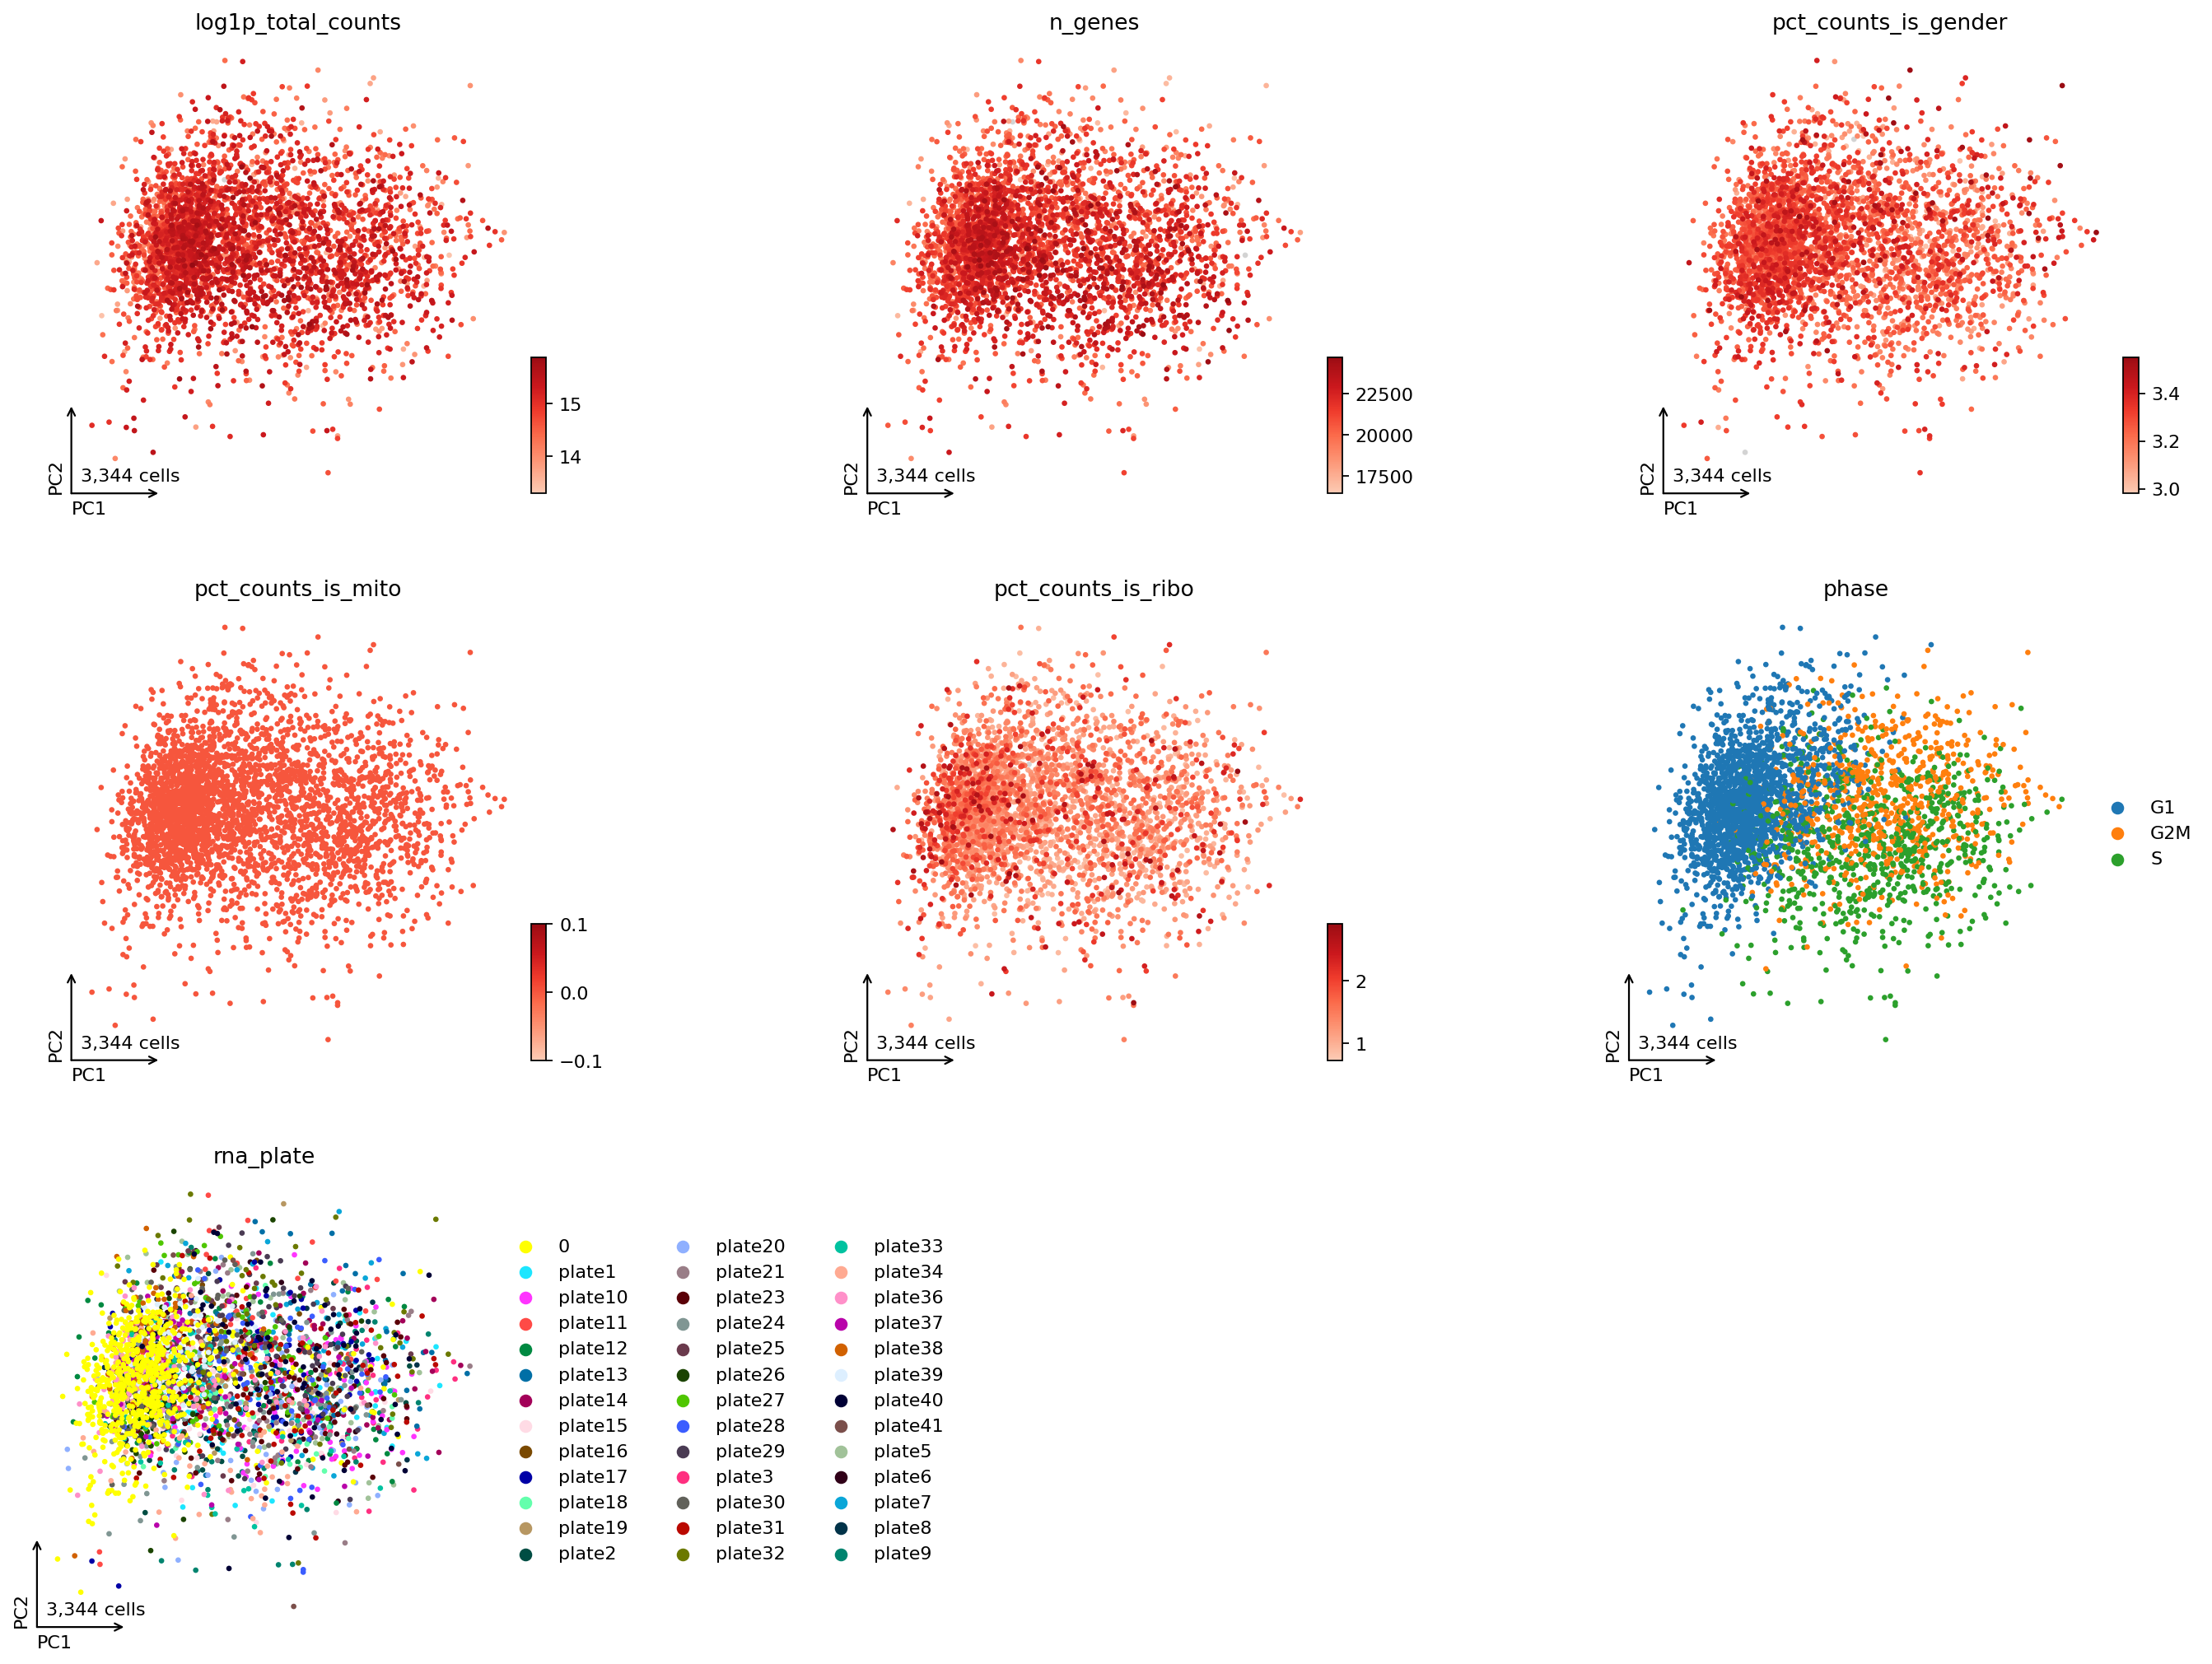

In [57]:
# Plot QC variables on the PCA embedding to show potential correlations
sctoolbox.plotting.embedding.plot_embedding(adata, method='pca', color=pca_color if pca_color else default_pca_color, ncols=3, show=False)
pl.general._save_figure("PCA_embedding.pdf")

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:143: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  res = corr_method(x[0], x[1])


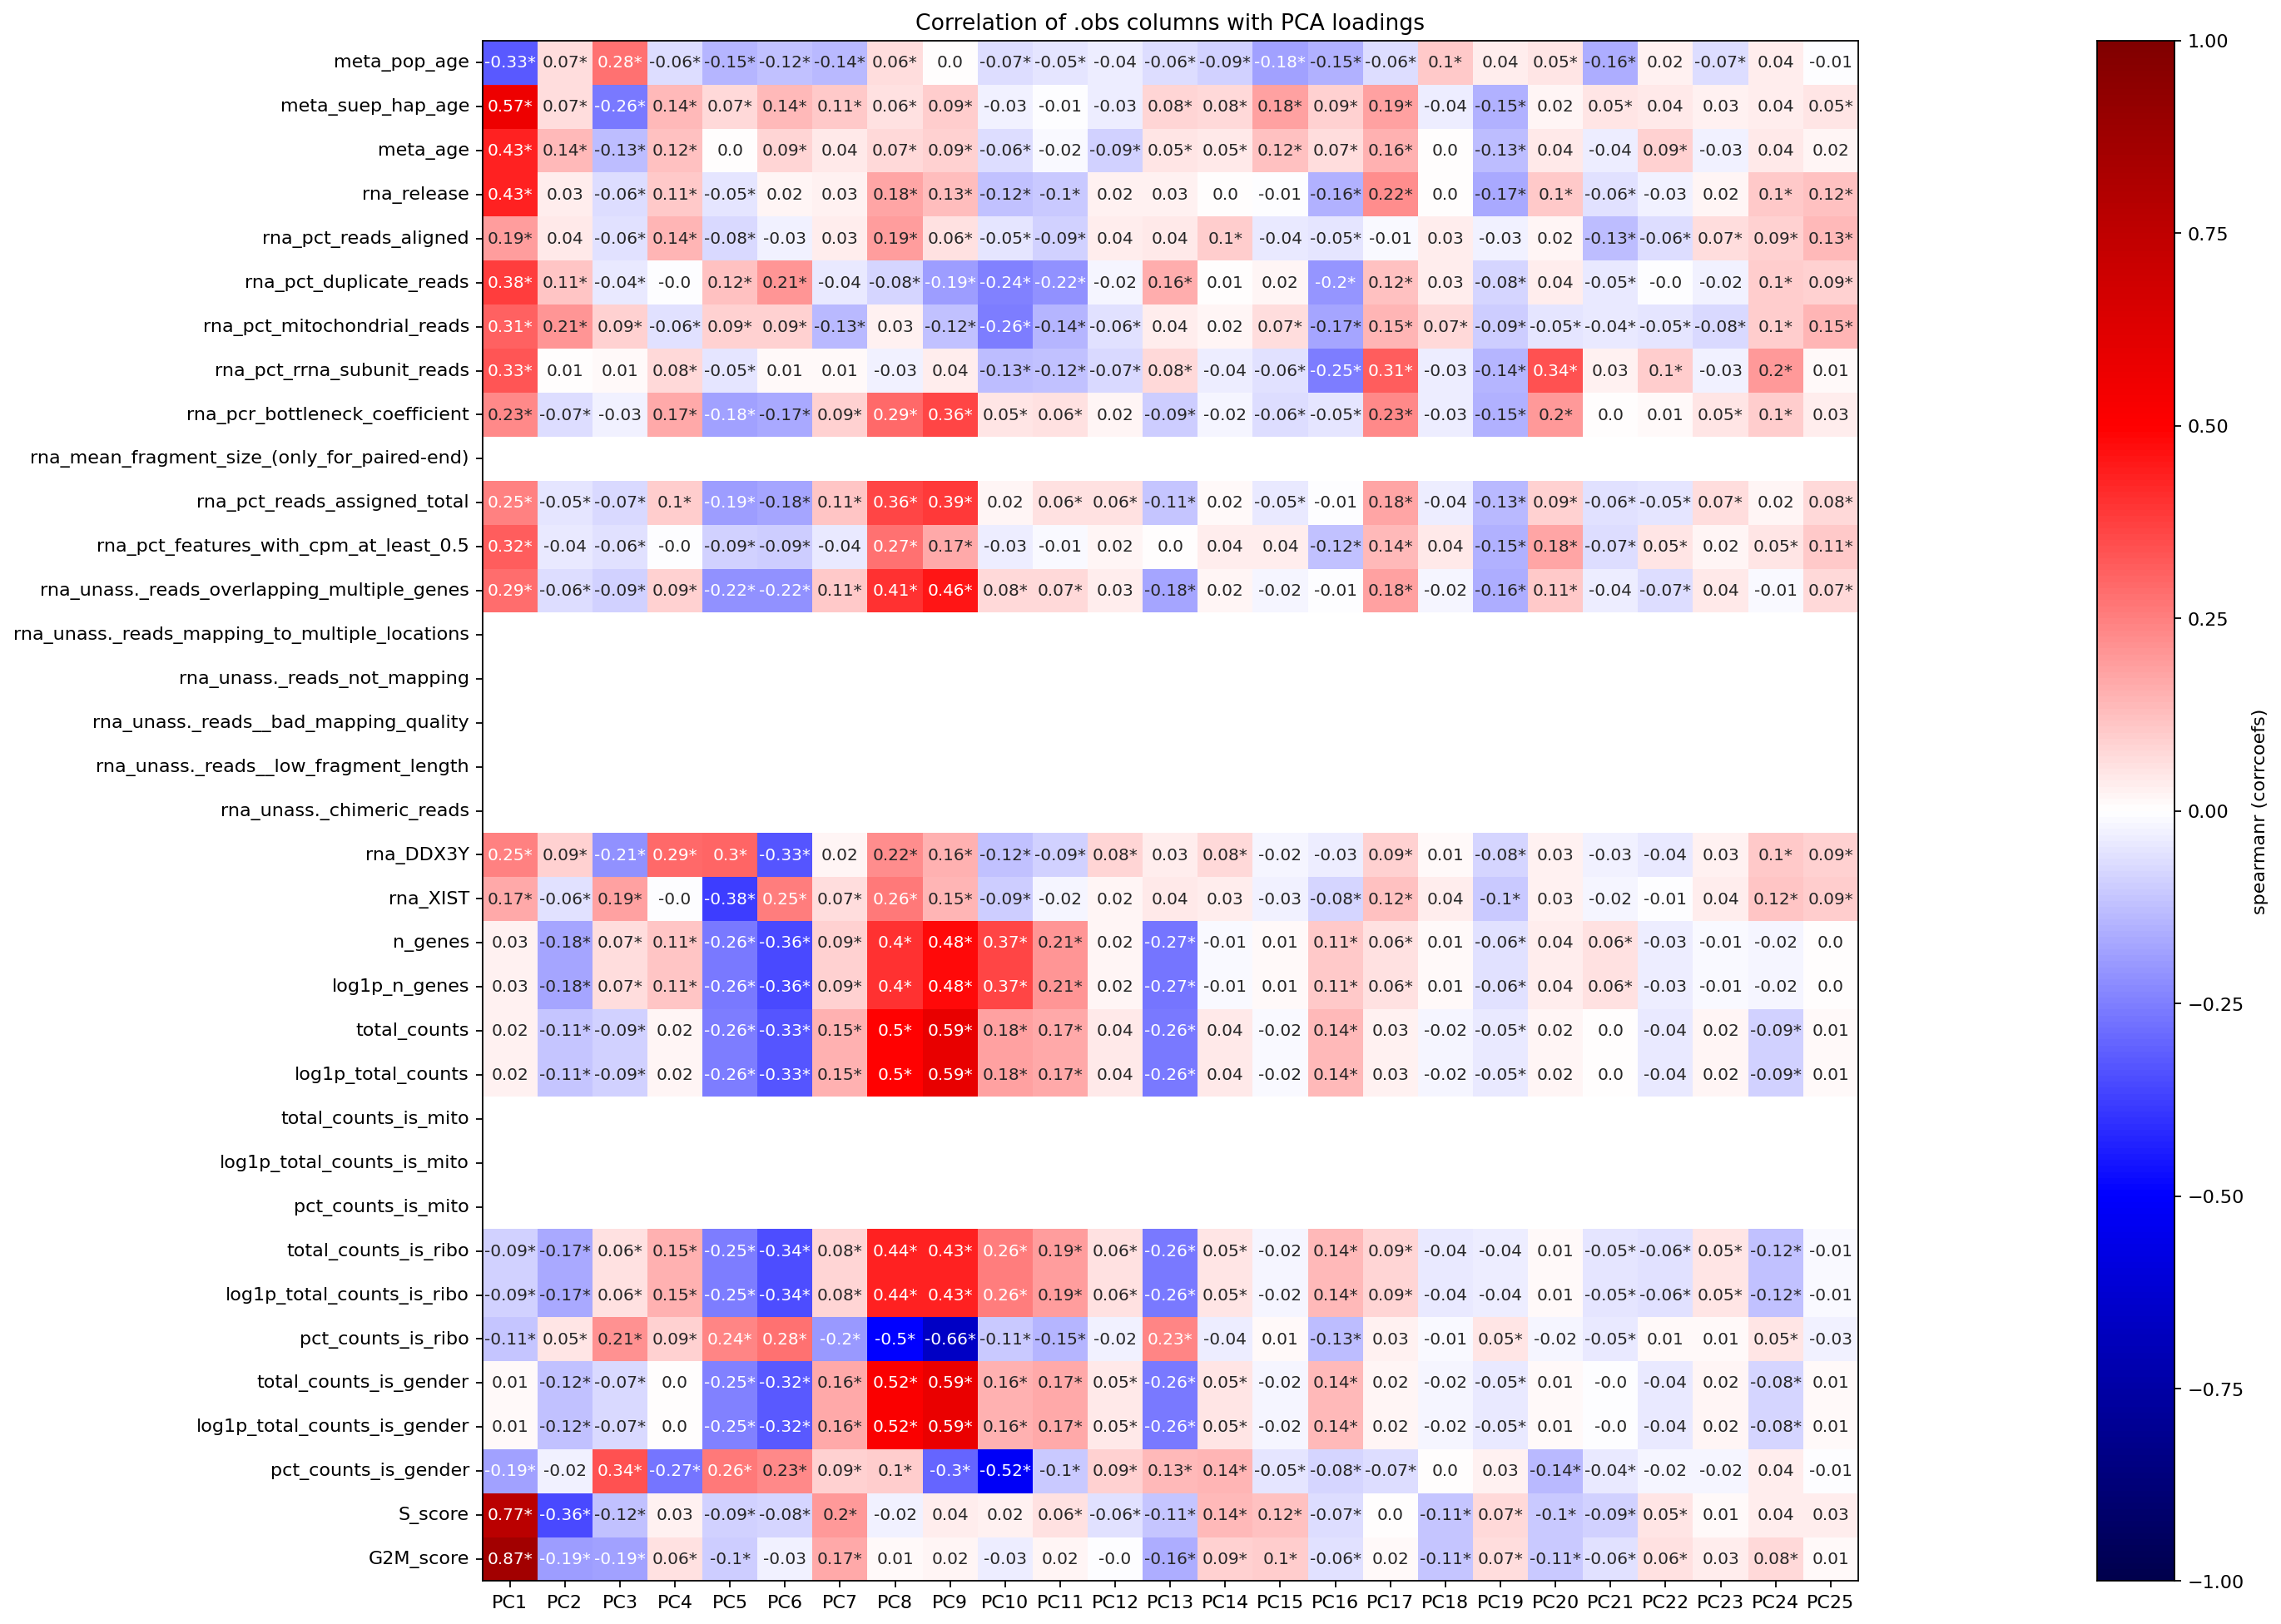

In [58]:
# PCA correlations with obs variables 
_ = pl.embedding.plot_pca_correlation(
    adata,
    n_components=n_pcs_heatmap,
    which="obs",
    title="Correlation of .obs columns with PCA loadings",
    save="PCA_correlation_obs.pdf"
)

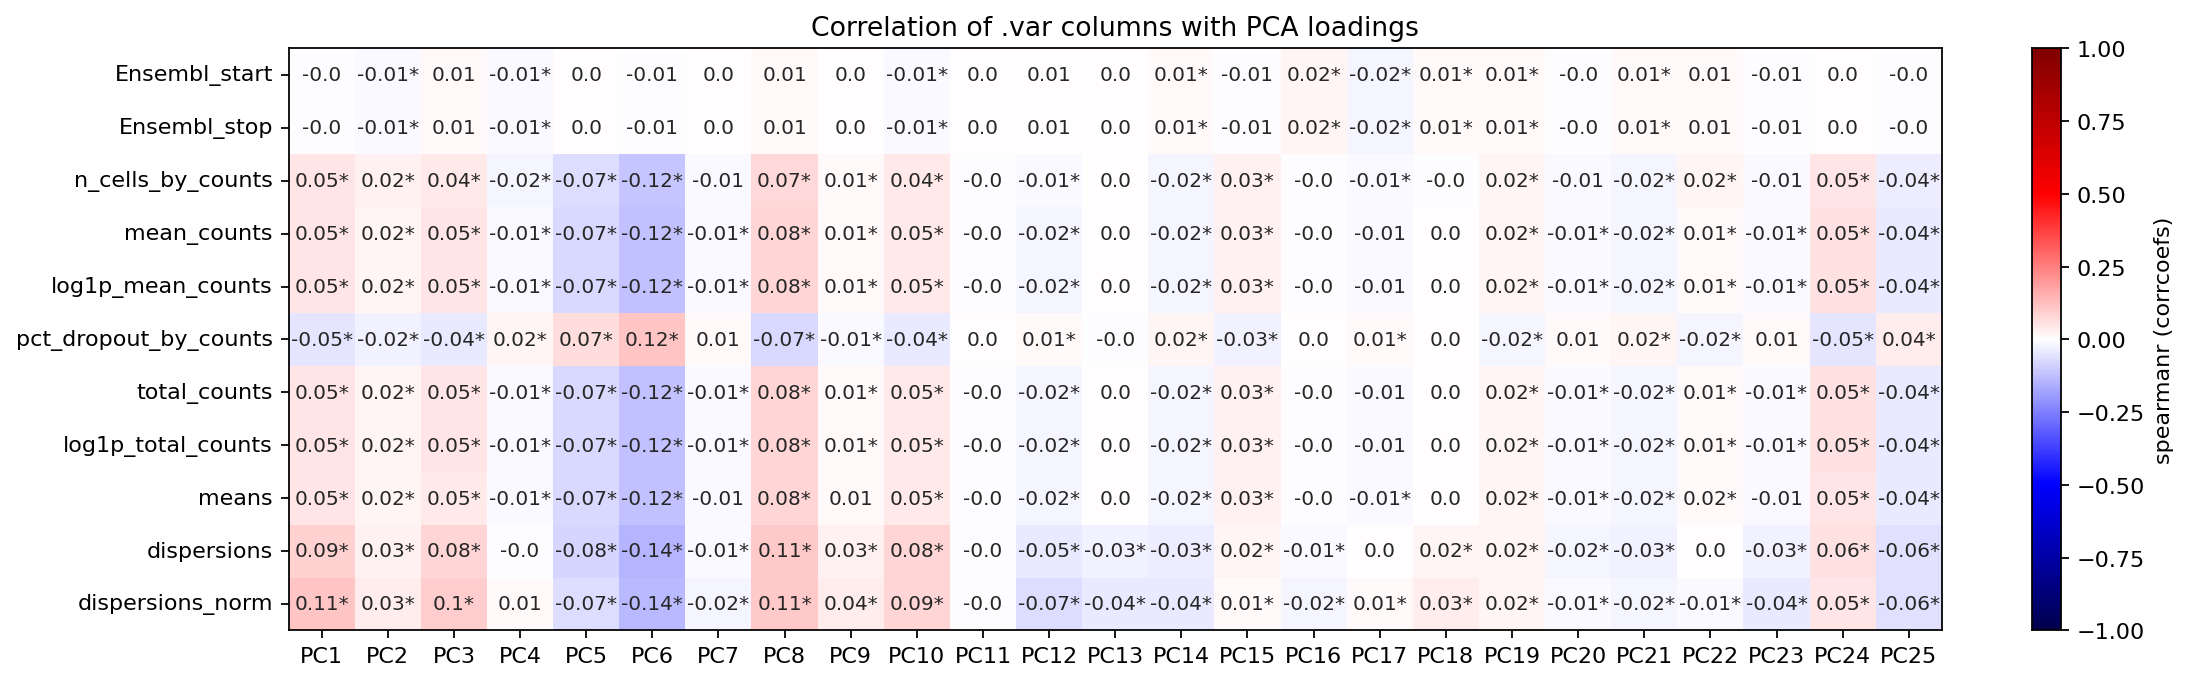

In [60]:
# PCA correlations with var variables
_ = pl.embedding.plot_pca_correlation(
    adata,
    n_components=n_pcs_heatmap,
    which="var",
    title="Correlation of .var columns with PCA loadings",
    save="PCA_correlation_var.pdf"
)

------------

### 9.2 - Choose a subset of PCs (optional)
<hr style="border:1px solid black"> </hr>

In case the above plots showed undesired correlation this section can be used to subset the PCs. The proposed PC subset is displayed as a plot with darker bars representing the selected PCs. Based on the selected `filter_methods`, a vertical and horizontal threshold line is displayed. PCs are filtered if they are below the horizontal threshold (`corr_thresh`) or if they are to the right of the vertical threshold line (`perc_thresh`).

#### 9.2.1 - Parameter Overview

| Parameter | Description | Options |
|:---:|:---|:---|
| subset_pcs | Whether the PCs should be filtered. | `True` or `False` |
| corr_thresh | Highest absolute correlation that is allowed. Will take the maximum correlation for each PC as shown in the heatmap above. PCs with an absolut correlation above this will be filtered | Expects a value between `0-1`. |
| perc_thresh | Top percentile of PCs that should be kept. | A value between `0-100`%. |
| filter_methods | The PCs will be filtered based on the given methods. E.g. for "variance" and "correlation" PCs are filtered on values from both methods and the intersection is used as the final subset. | Any combination of `["variance", "cumulative variance", "correlation"]` |
| basis | Compute correlation based on observations (cells) or variables (genes). | Either `obs` for cells or `var` for genes. |
|ignore_cols| List of column names to ignore for correlation | `None` or a list of column names|

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [90]:
subset_pcs = True

corr_thresh = 0.2
perc_thresh = 42
filter_methods = ['variance', 'correlation']
basis = 'obs'
ignore_cols = ['rna_mean_fragment_size_(only_for_paired-end)', 'rna_unass._reads_mapping_to_multiple_locations', 'rna_unass._reads_mapping_to_no_feature', 'rna_unass._reads_not_mapping', 'rna_unass._reads__bad_mapping_quality', 'rna_unass._reads__low_fragment_length', 'rna_unass._chimeric_reads','total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito']

___

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:121: UserWarning: Ignore columns ['rna_unass._reads_mapping_to_no_feature'] not present in table obs.
  warnings.warn(f"Ignore columns {invalid_ignore} not present in table {which}.")
/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:121: UserWarning: Ignore columns ['rna_unass._reads_mapping_to_no_feature'] not present in table obs.
  warnings.warn(f"Ignore columns {invalid_ignore} not present in table {which}.")


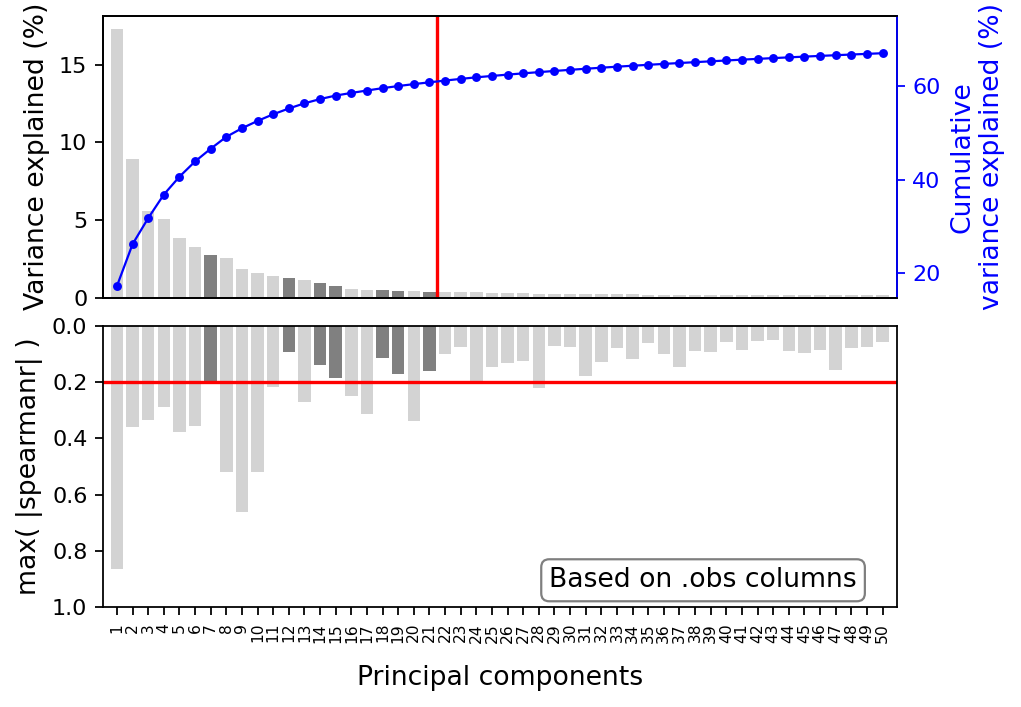

In [91]:
selected_pcs = tools.dim_reduction.propose_pcs(
    anndata=adata,
    how=filter_methods,
    corr_thresh=corr_thresh,
    perc_thresh=perc_thresh,
    corr_kwargs={'method': 'spearmanr', 'which': basis, 'ignore': ignore_cols}
)

# Plot and select number of PCs
_ = pl.embedding.plot_pca_variance(
    adata,
    selected=selected_pcs,
    save='PCA_variance_proposed_selection.pdf',
    n_pcs=50,
    n_thresh=max(selected_pcs),
    corr_plot='spearmanr',
    corr_thresh=corr_thresh,
    corr_on=basis,
    ignore=ignore_cols
)

In [92]:
f"Proposed principal components: {selected_pcs}"

'Proposed principal components: [7, 12, 14, 15, 18, 19, 21]'

Create a final PC-selection by changing the blue cell below:
- Either copy and adjust the proposed list from directly above
- create a custom list of PCs
- or accept the proposed list by not changing the cell below.

**Note: the selection will only be applied when `subset_pcs = True`.**

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [93]:
final_pc_selection = selected_pcs

___

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:121: UserWarning: Ignore columns ['rna_unass._reads_mapping_to_no_feature'] not present in table obs.
  warnings.warn(f"Ignore columns {invalid_ignore} not present in table {which}.")


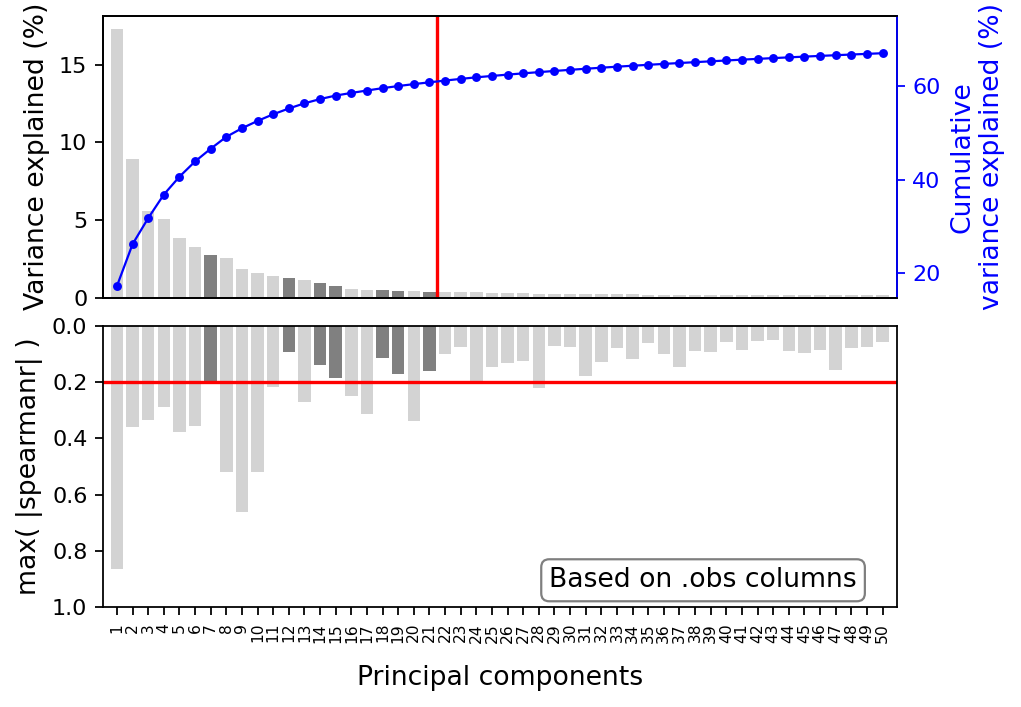

In [94]:
_ = pl.embedding.plot_pca_variance(
    adata, 
    selected=final_pc_selection if subset_pcs else None,
    save='PCA_variance_final_selection.pdf',
    n_pcs=50,
    n_thresh=max(selected_pcs) if subset_pcs else None,
    corr_plot='spearmanr',
    corr_thresh=corr_thresh if subset_pcs else None,
    corr_on=basis,
    ignore=ignore_cols
)

In [95]:
# Subset the number of pcs if chosen in the parameters
if subset_pcs:
    tools.dim_reduction.subset_PCA(adata, select=final_pc_selection)

------------

### 9.3 - Calculate neighbors
<hr style="border:1px solid black"> </hr>
This step constructs a graph connecting the cells with their k-nearest-neighbors based on the selected dimension reduction components. This graph represents the structure of the data and thus is used to detect clusters visualized in the UMAP in later steps.

#### 9.3.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| `n_neighbors` | Set the number of neighbors | Default 15 |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [96]:
n_neighbors = 15

In [97]:
sc.pp.neighbors(adata, n_neighbors=n_neighbors)

------------

## 10 - Batch correction
<hr style="border:1px solid black"> </hr>

Batch effects are variances in the data that are not intended by the experimental design (e.g. technical variance). They can be introduced through various sources. For example, sequencing samples at different timepoints may introduce batch effects. As batch effects could interfere with downstream analysis they are typically removed. However, it can be challenging to identify and correct for batch effects as this is highly dependent on the experimental setup of the dataset.

**DOI: [10.1038/nrg2825](https://doi.org/10.1038/nrg2825)**

There are several batch correction methods available, which may perform differently depending on the data set. Therefore, an overview is provided to compare batch correction methods and select the best performing one. To help in the decision making process, several metrics are shown that can be selected below and a score (LISI) is provided that explains whether the batches are well mixed after applying the correction.

### 10.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| perform_batch_correction | Whether or not you want to do batch correction | `True` or `False` |
| batch_methods | A list of methods for batch correction | `bbknn`, `mnn`, `harmony`, `scanorama`, `combat` or list more than one method |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [98]:
perform_batch_correction = True
batch_methods = ["bbknn", "mnn", "harmony", "scanorama"] # , combat (excluded in this example due to slow runtime)

In [99]:
if perform_batch_correction:
    batch_corrections = tools.norm_correct.wrap_corrections(
        adata, 
        batch_key=batch_column,
        methods=batch_methods
    )
else:
    batch_corrections = {"uncorrected": adata}

[INFO] Running batch correction with 'bbknn'...
[INFO] Running batch correction with 'mnn'...
[INFO] Running batch correction with 'harmony'...
[INFO] Running batch correction with 'scanorama'...
[[0.         0.86746988 0.87209302 ... 0.90625    0.67045455 0.83050847]
 [0.         0.         0.21686747 ... 0.22891566 0.22891566 0.18644068]
 [0.         0.         0.         ... 0.34375    0.32954545 0.45762712]
 ...
 [0.         0.         0.         ... 0.         0.54545455 0.375     ]
 [0.         0.         0.         ... 0.         0.         0.52272727]
 [0.         0.         0.         ... 0.         0.         0.        ]]
Processing datasets 0 <=> plate19
Processing datasets 0 <=> plate34
Processing datasets 0 <=> plate37
Processing datasets 0 <=> plate36
Processing datasets 0 <=> plate16
Processing datasets 0 <=> plate38
Processing datasets 0 <=> plate5
Processing datasets 0 <=> plate11
Processing datasets 0 <=> plate14
Processing datasets 0 <=> plate24
Processing datasets 0

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/scanpy/external/pp/_scanorama_integrate.py:148: ImplicitModificationWarning: Setting element `.obsm['X_scanorama']` of view, initializing view as actual.
  adata.obsm[adjusted_basis] = np.concatenate(integrated)


[INFO] Finished batch correction(s)!


------------

### 10.2 - Plot overview of batch corrections

In [100]:
# Run standard umap for all adatas
tools.embedding.wrap_umap(batch_corrections.values(), threads=threads)

Computing UMAPs :   0%|          | 0/5 [00:00<?, ?it/s]

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/tools/embedding.py:49: ImplicitModificationWarning: Setting element `.obsm['X_umap']` of view, initializing view as actual.
  adata.obsm["X_umap"] = adata_return.obsm["X_umap"]


In [101]:
default_embed_color = [k for k in adata.uns["sctoolbox"]["report"]["qc"]["obs"]["threshold"].keys() if k not in ["before", "after"]] + ["phase", batch_column]
default_embed_color

['log1p_total_counts',
 'n_genes',
 'pct_counts_is_gender',
 'pct_counts_is_mito',
 'pct_counts_is_ribo',
 'phase',
 'rna_plate']

#### 10.2.1 - Parameter Overview

| Parameter | Description | Options |
|-----------|-------------|---------|
| embed_color | Metrics shown in the following PCA and UMAP | only `batch_column`, a list of columns in `obs` or `var`, or leave it empty to use `default_embed_color` (see above) for relevant metrics |
| do_clustering | Whether or not preliminary clustering should be performed | `True` or `False`

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [102]:
embed_color = [batch_column]

do_clustering = True

___

In [103]:
if do_clustering:
    for adata in batch_corrections.values():
        sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
    
    (embed_color if embed_color else default_embed_color).append("leiden")

**LISI score:**  
To determine the strength of a batch effect the Local Inverse Simpson's Index (LISI) can be used by measuring the heterogeneity within a local group. Comparing the LISI score between uncorrected data and the batch correction methods can help in deciding which method performed best.  
The LISI score (stored in `adata.obs`) indicates the effective number of different categories represented in the local neighborhood of each cell. If the cells are well-mixed, then we expect the LISI score to be closer to `n` for a dataset with `n` batches.

**DOI: [10.1038/s41592-019-0619-0](https://doi.org/10.1038/s41592-019-0619-0)**

**The higher the LISI score is, the better the batch correction method worked to normalize the batch effect and mix the cells from different batches.**


In [104]:
# Calculate LISI scores for batch
tools.norm_correct.wrap_batch_evaluation(batch_corrections, batch_key=batch_column, threads=threads, inplace=True)

Calculating LISI scores:   0%|          | 0/10 [00:00<?, ?it/s]

/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/embedding.py:1951: UserWarning: The palette list has more values (20) than needed (7), which may not be intended.
  sns.barplot(x=x,
/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/embedding.py:1951: UserWarning: The palette list has more values (20) than needed (7), which may not be intended.
  sns.barplot(x=x,
/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/embedding.py:1951: UserWarning: The palette list has more values (20) than needed (7), which may not be intended.
  sns.barplot(x=x,
/home/stud9/.conda/envs/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/embedding.py:1951: UserWarning: The palette list has more values (20) than needed (7), which may not be intended.
  sns.barplot(x=x,


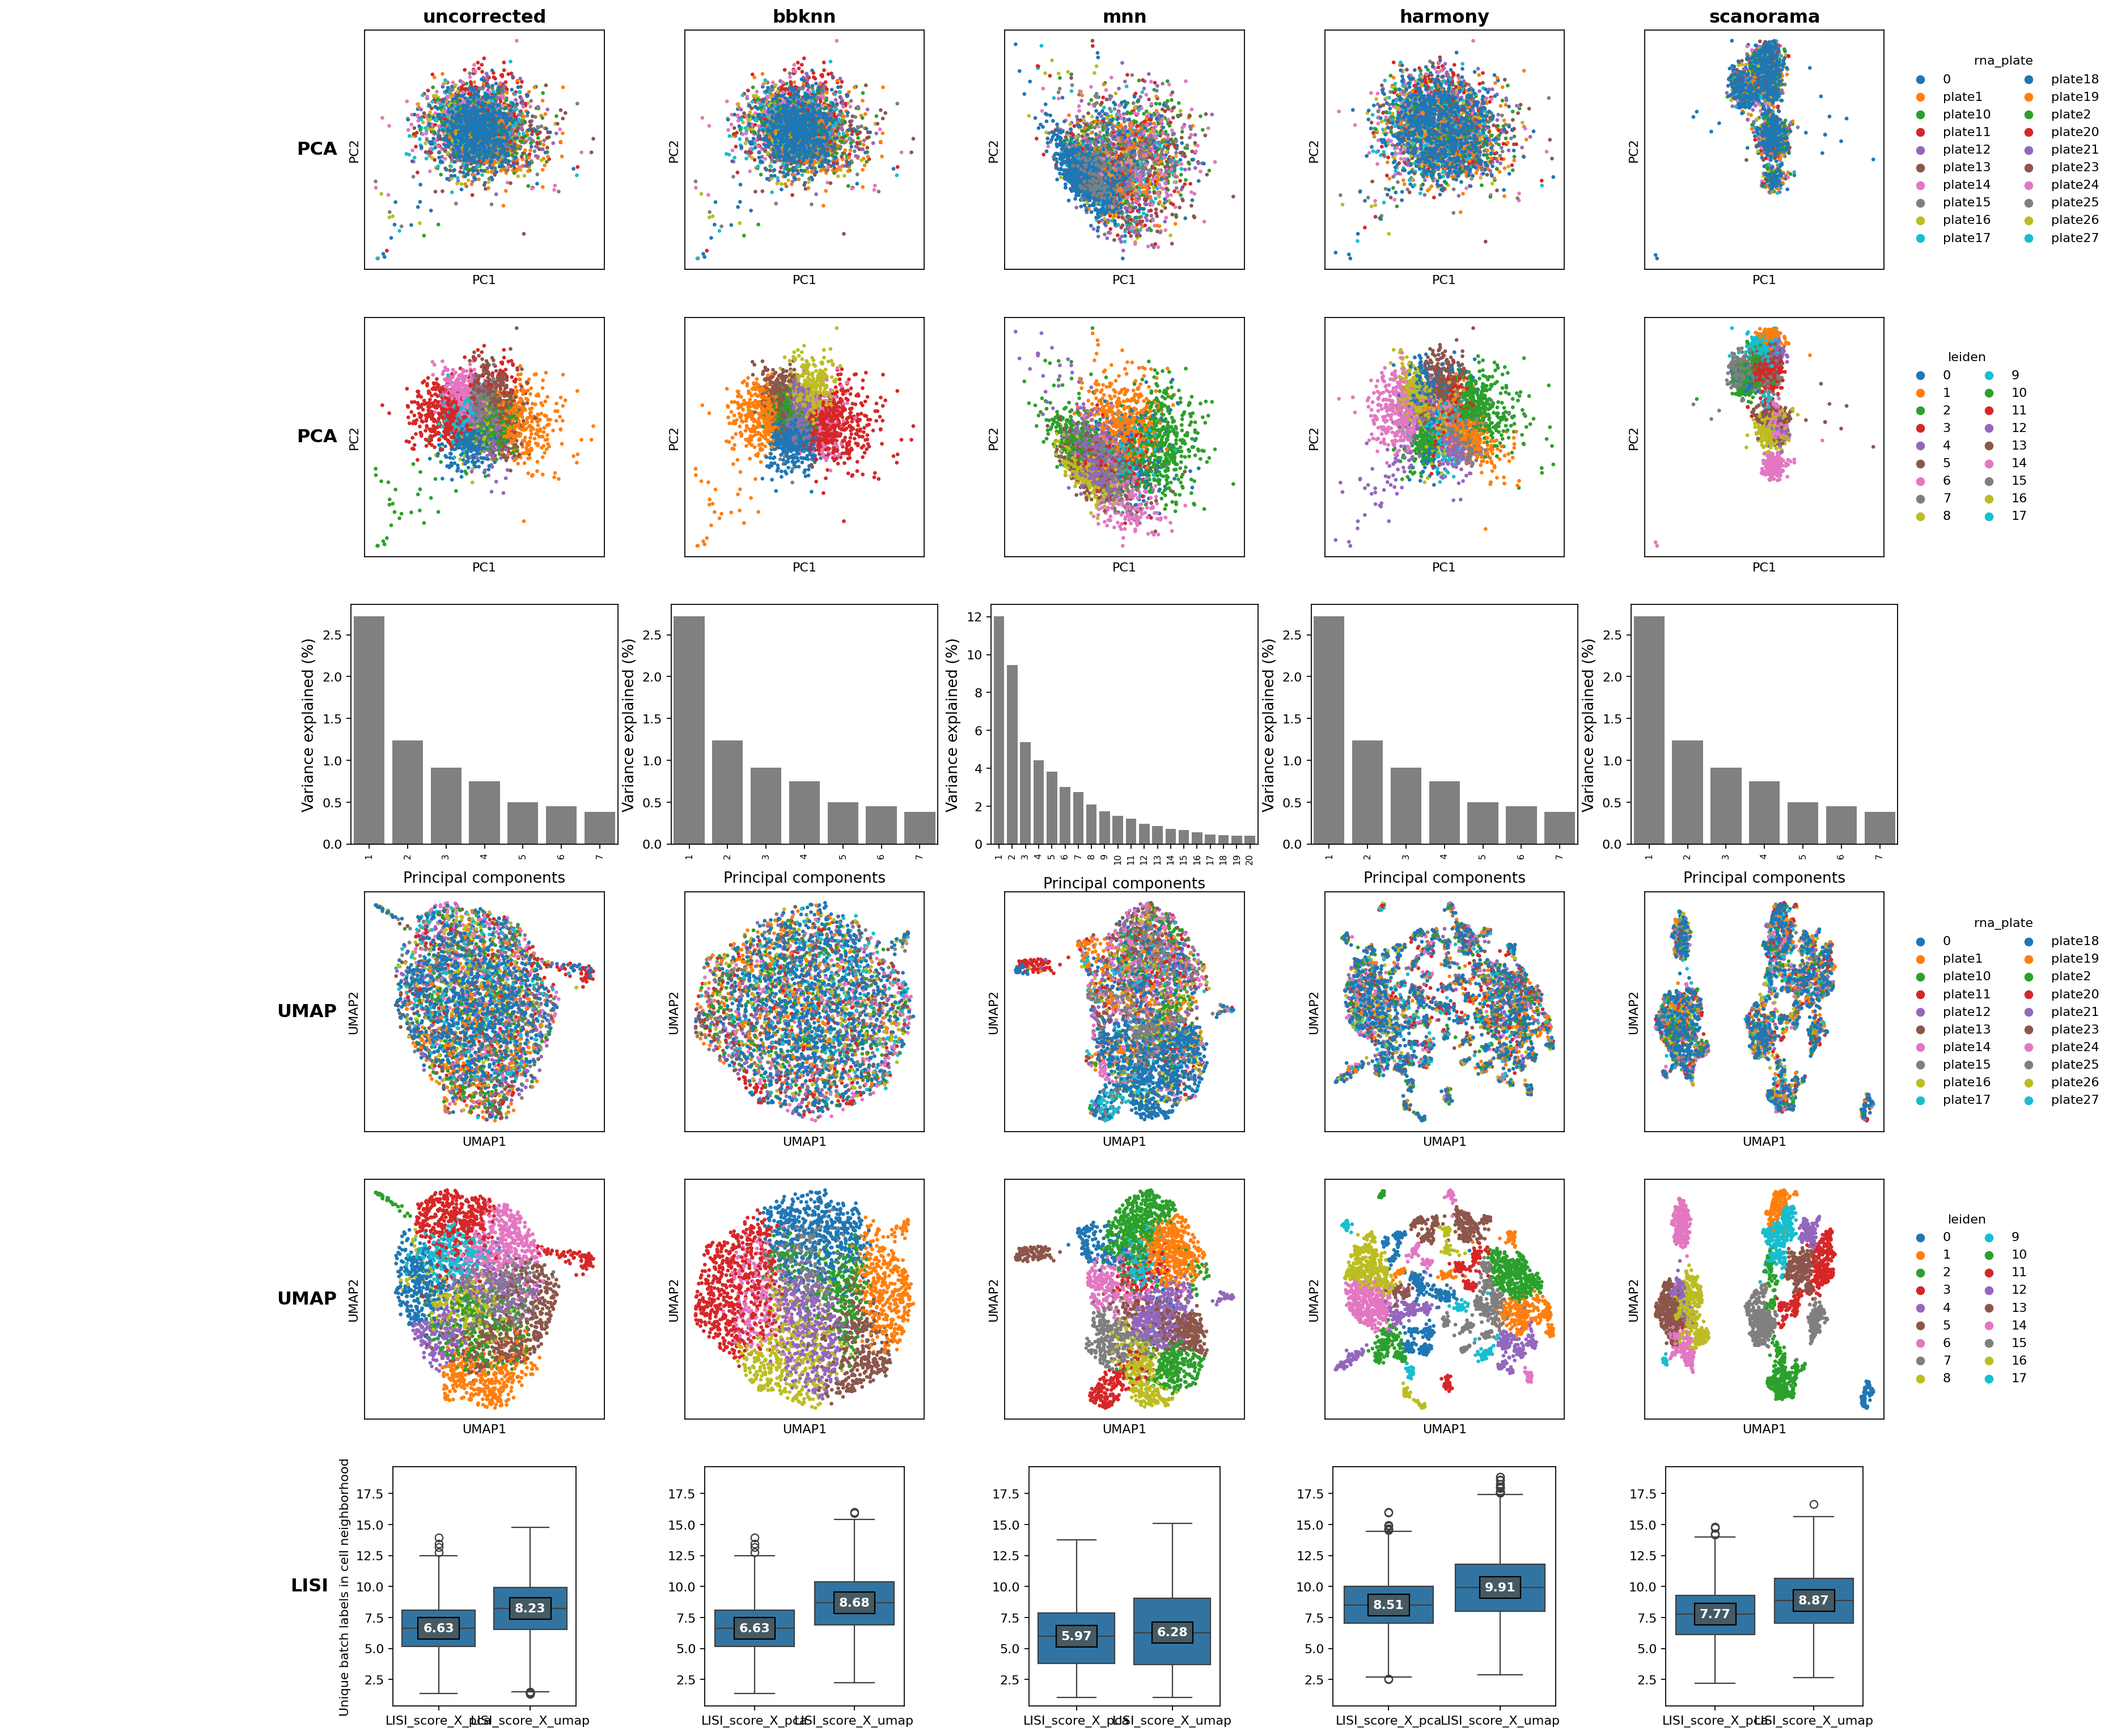

In [105]:
# Plot the overview of batch correction methods
_ = pl.embedding.anndata_overview(
    batch_corrections,
    color_by=embed_color if embed_color else default_embed_color, 
    output="batch_correction_overview.pdf"
)

------------

Choose a batch correction method object to proceed:

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [106]:
selected = "scanorama"

___

In [107]:
if not perform_batch_correction and selected != "uncorrected":
    import warnings
    warnings.warn(f"Selected batch correction '{selected}' but batch correction is disabled. Falling back to 'uncorrected'.")
    
    selected = "uncorrected"
elif selected not in batch_corrections:
    raise KeyError(f"'{selected}' is not a key in batch_corrections. Choose one of: {list(batch_corrections.keys())}")

In [108]:
adata = batch_corrections[selected]

-------------

## 11 - Saving adata for the next notebook

In [109]:
adata

AnnData object with n_obs × n_vars = 3344 × 57031
    obs: 'TubeID', 'meta_TubeID', 'meta_pop_export_psn', 'meta_pop_visit_1_date', 'meta_pop_visit_2_date', 'meta_pop_visit_3_date', 'meta_pop_visit_4_date', 'meta_pop_age', 'meta_pop_age_dec', 'meta_pop_sex', 'meta_pop_c19_severity', 'meta_pop_cohort', 'meta_suep_hap_export_psn', 'meta_suep_hap_baseline_date', 'meta_suep_hap_end_acute_date', 'meta_suep_hap_end_acute_visit_date', 'meta_suep_hap_m3_fu_date', 'meta_suep_hap_m6_fu_date', 'meta_suep_hap_m12_fu_date', 'meta_suep_hap_m24_fu_date', 'meta_suep_hap_age', 'meta_suep_hap_age_dec', 'meta_suep_hap_sex', 'meta_suep_hap_c19_severity', 'meta_suep_hap_cohort', 'meta_export_psn', 'meta_age', 'meta_age_dec', 'meta_sex', 'meta_c19_severity', 'meta_cohort', 'rna_TubeID', 'rna_id', 'rna_fastq1', 'rna_project', 'rna_run', 'rna_plate', 'rna_organism', 'rna_assembly', 'rna_release', 'rna_parameters', 'rna_reads_processed', 'rna_reads_with_exactly_1_alignment', 'rna_reads_with_multiple_alignments

In [110]:
#Saving the data
adata_output = "anndata_3.h5ad"
utils.adata.save_h5ad(adata, adata_output)

[INFO] The adata object was saved to: ../adatas/anndata_3.h5ad


In [111]:
sctoolbox.settings.close_logfile()